# Spotify Playlist Reconstruction - Data Exploration

## Task 1
Following a hacker attack on Spotify's servers, we need to reconstruct Top-of-the-Year playlists for each user. We have:
- **3,500 labeled songs** with known `user` and `top_year`
- **100 unlabeled songs** (marked "deleted by hacker") that need prediction
Our goal is to explore the dataset to understand patterns that will help us predict the missing labels.
### 1. Load Libraries


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### 2. Load Data & Inspect Structure

In [2]:
# Load the dataset
df = pd.read_csv('mixed_playlist.csv')

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (3600, 22)

Column names:
['name', 'album', 'artist', 'release_date', 'length', 'popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'time_signature', 'key', 'mode', 'uri', 'release_year', 'top_year', 'user']

Data types:
name                 object
album                object
artist               object
release_date         object
length                int64
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
time_signature        int64
key                   int64
mode                  int64
uri                  object
release_year          int64
top_year             object
user                 object
dtype: object


In [3]:
# Preview first few rows
df.head()

,name,album,artist,release_date,length,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,time_signature,key,mode,uri,release_year,top_year,user
0,"Variations on a Polish Theme, Op. 10: No. 5 An...","Szymanowski: Piano Works, Vol. 2",Karol Szymanowski,06/12/1996,76933,53,0.9960,0.329,0.00695,0.866000,0.0906,-34.227,0.0448,70.295,0.238,4,11,0,spotify:track:3bcdLMrAxrfn5dxInjIdI2,1996,deleted by hacker,deleted by hacker
1,Je vous trouve un charme fou - En duo avec Gaë...,Il suffit d'y croire (Version deluxe),Hoshi,2018-11-30,172626,62,0.6220,0.615,0.59900,0.000008,0.1920,-8.715,0.2530,86.976,0.626,4,1,1,spotify:track:0C2yaSWVgCUiiqPyYxSOkd,2018,2025,delta
2,Me Gusta,On ira où ?,DTF,2019-10-11,175269,72,0.4130,0.834,0.73400,0.000040,0.1130,-5.948,0.3410,89.989,0.356,4,6,0,spotify:track:6P3FBaZfUjeWYExU2ShaPZ,2019,2023,gamma
3,L’amour en Solitaire,Petite Amie (Deluxe),Juliette Armanet,2018-02-02,175266,0,0.4040,0.797,0.50600,0.000153,0.2550,-6.774,0.0327,128.027,0.539,4,5,0,spotify:track:2tn51grfchxArwPXeXkoX5,2018,2021,gamma
4,Goodnight Moon,Volta,Boogie Belgique,2016-09-23,264735,53,0.0616,0.788,0.67500,0.711000,0.1000,-8.591,0.0318,107.993,0.525,4,7,0,spotify:track:2rvo9Ddv18aRV0OJldhWTf,2016,2023,alpha


In [4]:
# Standardize release_date format to YYYY-DD-MM
def standardize_date(date_str):
    """Convert various date formats to YYYY-DD-MM. Assign 01-01 for missing day/month."""
    if pd.isna(date_str):
        return date_str
    
    date_str = str(date_str).strip()
    
    # If only year (4 digits)
    if date_str.isdigit() and len(date_str) == 4:
        return f"{date_str}-01-01"
    
    # Try parsing different formats
    try:
        # Format: YYYY-MM-DD
        if '-' in date_str and len(date_str) == 10 and date_str[4] == '-':
            parts = date_str.split('-')
            return f"{parts[0]}-{parts[2]}-{parts[1]}"  # YYYY-DD-MM
        
        # Format: DD/MM/YYYY
        if '/' in date_str:
            parts = date_str.split('/')
            if len(parts) == 3:
                return f"{parts[2]}-{parts[0]}-{parts[1]}"  # YYYY-DD-MM
        
        return date_str
    except:
        return date_str
    
df['release_date'] = df['release_date'].apply(standardize_date)

In [5]:
# Preview first few rows after date transformation
df.head()

,name,album,artist,release_date,length,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,time_signature,key,mode,uri,release_year,top_year,user
0,"Variations on a Polish Theme, Op. 10: No. 5 An...","Szymanowski: Piano Works, Vol. 2",Karol Szymanowski,1996-06-12,76933,53,0.9960,0.329,0.00695,0.866000,0.0906,-34.227,0.0448,70.295,0.238,4,11,0,spotify:track:3bcdLMrAxrfn5dxInjIdI2,1996,deleted by hacker,deleted by hacker
1,Je vous trouve un charme fou - En duo avec Gaë...,Il suffit d'y croire (Version deluxe),Hoshi,2018-30-11,172626,62,0.6220,0.615,0.59900,0.000008,0.1920,-8.715,0.2530,86.976,0.626,4,1,1,spotify:track:0C2yaSWVgCUiiqPyYxSOkd,2018,2025,delta
2,Me Gusta,On ira où ?,DTF,2019-11-10,175269,72,0.4130,0.834,0.73400,0.000040,0.1130,-5.948,0.3410,89.989,0.356,4,6,0,spotify:track:6P3FBaZfUjeWYExU2ShaPZ,2019,2023,gamma
3,L’amour en Solitaire,Petite Amie (Deluxe),Juliette Armanet,2018-02-02,175266,0,0.4040,0.797,0.50600,0.000153,0.2550,-6.774,0.0327,128.027,0.539,4,5,0,spotify:track:2tn51grfchxArwPXeXkoX5,2018,2021,gamma
4,Goodnight Moon,Volta,Boogie Belgique,2016-23-09,264735,53,0.0616,0.788,0.67500,0.711000,0.1000,-8.591,0.0318,107.993,0.525,4,7,0,spotify:track:2rvo9Ddv18aRV0OJldhWTf,2016,2023,alpha


In [6]:
# Identify labeled vs unlabeled data
labeled = df[df['user'] != 'deleted by hacker']
unlabeled = df[df['user'] == 'deleted by hacker']

print(f"Labeled songs: {len(labeled)}")
print(f"Unlabeled songs: {len(unlabeled)}")
print(f"\nUnlabeled rows sample:")
unlabeled.head()

Labeled songs: 3500
Unlabeled songs: 100

Unlabeled rows sample:


,name,album,artist,release_date,length,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,time_signature,key,mode,uri,release_year,top_year,user
0,"Variations on a Polish Theme, Op. 10: No. 5 An...","Szymanowski: Piano Works, Vol. 2",Karol Szymanowski,1996-06-12,76933,53,0.996,0.329,0.00695,0.866,0.0906,-34.227,0.0448,70.295,0.2380,4,11,0,spotify:track:3bcdLMrAxrfn5dxInjIdI2,1996,deleted by hacker,deleted by hacker
66,For J√≥hann,Bach Reworks (Pt. 1),V√≠kingur √ìlafsson,2018-05-10,183773,22,0.994,0.629,0.09140,0.947,0.0864,-33.589,0.0406,111.454,0.2410,4,0,0,spotify:track:5BzsTKLEKQMDhPwbCZOrn5,2018,deleted by hacker,deleted by hacker
71,"Concerto For Piano And Orchestra In G, Second ...",Gershwin's World,Herbie Hancock,1998-01-01,551666,20,0.981,0.208,0.09940,0.919,0.0843,-20.559,0.0342,62.543,0.0420,4,4,1,spotify:track:4rL06iWdtarlSqlxgU2N14,1998,deleted by hacker,deleted by hacker
83,This Reminds You - Satie Remix,Shadows,Remy Van Kesteren,2019-15-02,321146,26,0.870,0.258,0.05890,0.898,0.1480,-23.782,0.0381,98.874,0.0378,4,5,0,spotify:track:3rruI72VDoIINSuAhryTOL,2019,deleted by hacker,deleted by hacker
138,Sull Lull,Madar,Jan Garbarek,1992-01-01,1009706,27,0.913,0.502,0.30400,0.857,0.0914,-16.618,0.0473,105.740,0.5590,4,7,0,spotify:track:3DzBR3hE8hzutFqlB1jjmk,1992,deleted by hacker,deleted by hacker


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
name                9
album               9
artist              0
release_date        0
length              0
popularity          0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
time_signature      0
key                 0
mode                0
uri                 0
release_year        0
top_year            0
user                0
dtype: int64


In [8]:
# Remove rows with missing values
print(f"Shape before removing missing values: {df.shape}")
df = df.dropna()
print(f"Shape after removing missing values: {df.shape}")

# Update labeled and unlabeled dataframes
labeled = df[df['user'] != 'deleted by hacker']
unlabeled = df[df['user'] == 'deleted by hacker']
print(f"\nLabeled songs: {len(labeled)}")
print(f"Unlabeled songs: {len(unlabeled)}")

Shape before removing missing values: (3600, 22)
Shape after removing missing values: (3591, 22)

Labeled songs: 3491
Unlabeled songs: 100


### 3. Examine Target Variables

We need to predict two target variables:
- **user**: Which family member the song belongs to (5 classes)
- **top_year**: Which year's Top-of-the-Year playlist (2019-2025)

User distribution:
user
gamma      700
beta       700
alpha      700
delta      696
epsilon    695
Name: count, dtype: int64


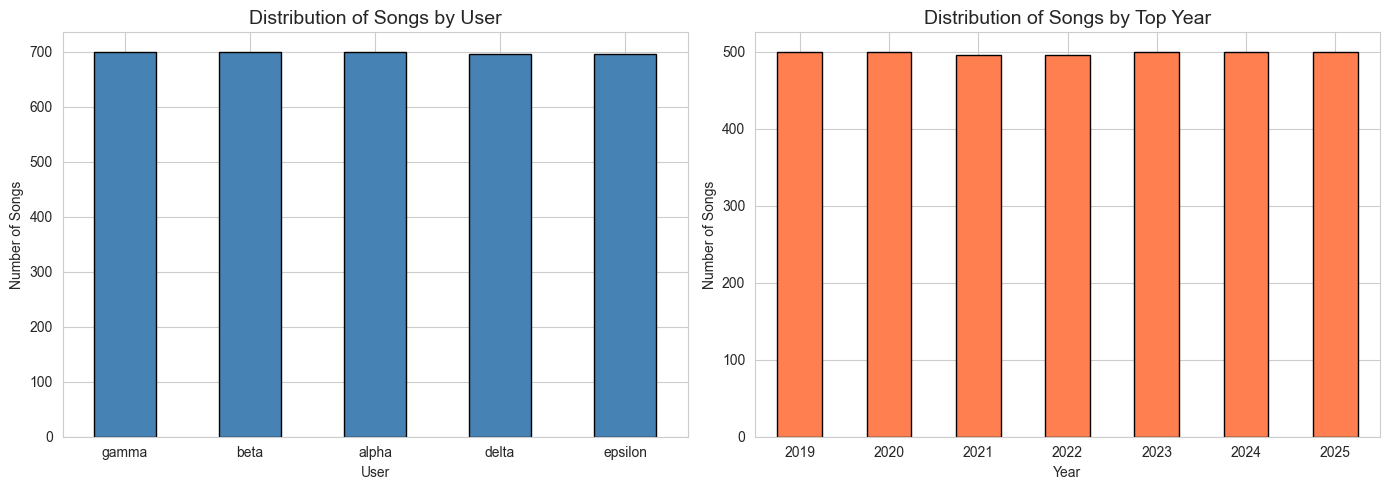

In [9]:
# Analyze user distribution (labeled data only)
print("User distribution:")
print(labeled['user'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User distribution
labeled['user'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Songs by User', fontsize=14)
axes[0].set_xlabel('User')
axes[0].set_ylabel('Number of Songs')
axes[0].tick_params(axis='x', rotation=0)

# Top year distribution
labeled['top_year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribution of Songs by Top Year', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Songs')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Songs per User per Year:
top_year  2019  2020  2021  2022  2023  2024  2025
user                                              
alpha      100   100   100   100   100   100   100
beta       100   100   100   100   100   100   100
delta      100   100   100    96   100   100   100
epsilon    100   100    95   100   100   100   100
gamma      100   100   100   100   100   100   100


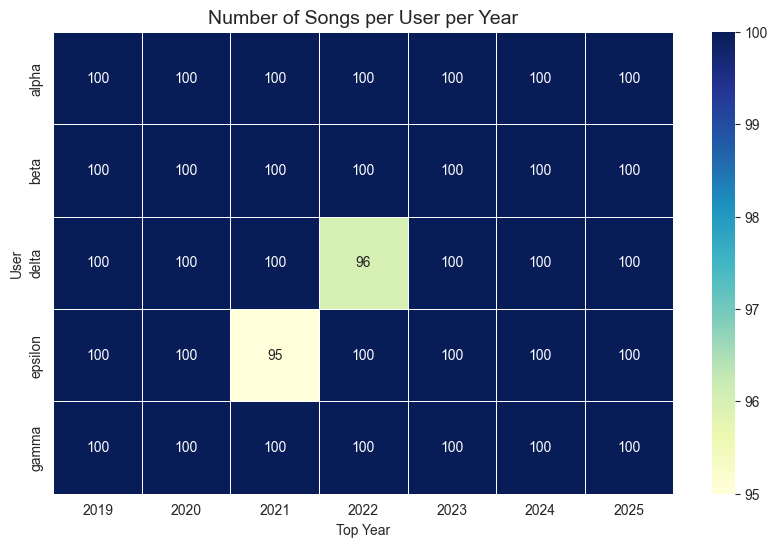

In [10]:
# Cross-tabulation: Songs per user per year
user_year_crosstab = pd.crosstab(labeled['user'], labeled['top_year'])
print("Songs per User per Year:")
print(user_year_crosstab)

# Heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(user_year_crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Number of Songs per User per Year', fontsize=14)
plt.xlabel('Top Year')
plt.ylabel('User')
plt.show()

### 4. Explore Audio Features

We have 9 audio features from Spotify's API plus additional metadata. Let's understand their distributions.

In [11]:
# Define feature columns
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
metadata_features = ['time_signature', 'key', 'mode', 'popularity', 'length', 'release_year']

all_features = audio_features + metadata_features

# Summary statistics for audio features
print("Summary Statistics for Audio Features:")
labeled[audio_features].describe()

Summary Statistics for Audio Features:


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,3491.000000,3491.000000,3491.000000,3491.000000,3491.000000,3491.000000,3491.000000,3491.000000,3491.000000
mean,0.442310,0.561929,0.510182,0.266938,0.163630,-10.539973,0.085835,115.299507,0.391452
std,0.357104,0.194152,0.258713,0.376518,0.140566,6.240242,0.094178,28.868427,0.257052
min,0.000011,0.000000,0.000545,0.000000,0.017900,-42.117000,0.000000,0.000000,0.000000
25%,0.080250,0.434000,0.306000,0.000002,0.093850,-12.877500,0.036500,93.895000,0.164000
50%,0.382000,0.586000,0.534000,0.002080,0.111000,-8.715000,0.046700,115.003000,0.364000
75%,0.799000,0.710000,0.721000,0.684000,0.168000,-6.304500,0.087300,131.377500,0.585000
max,0.996000,0.971000,0.991000,0.995000,0.991000,-0.908000,0.952000,209.596000,0.981000


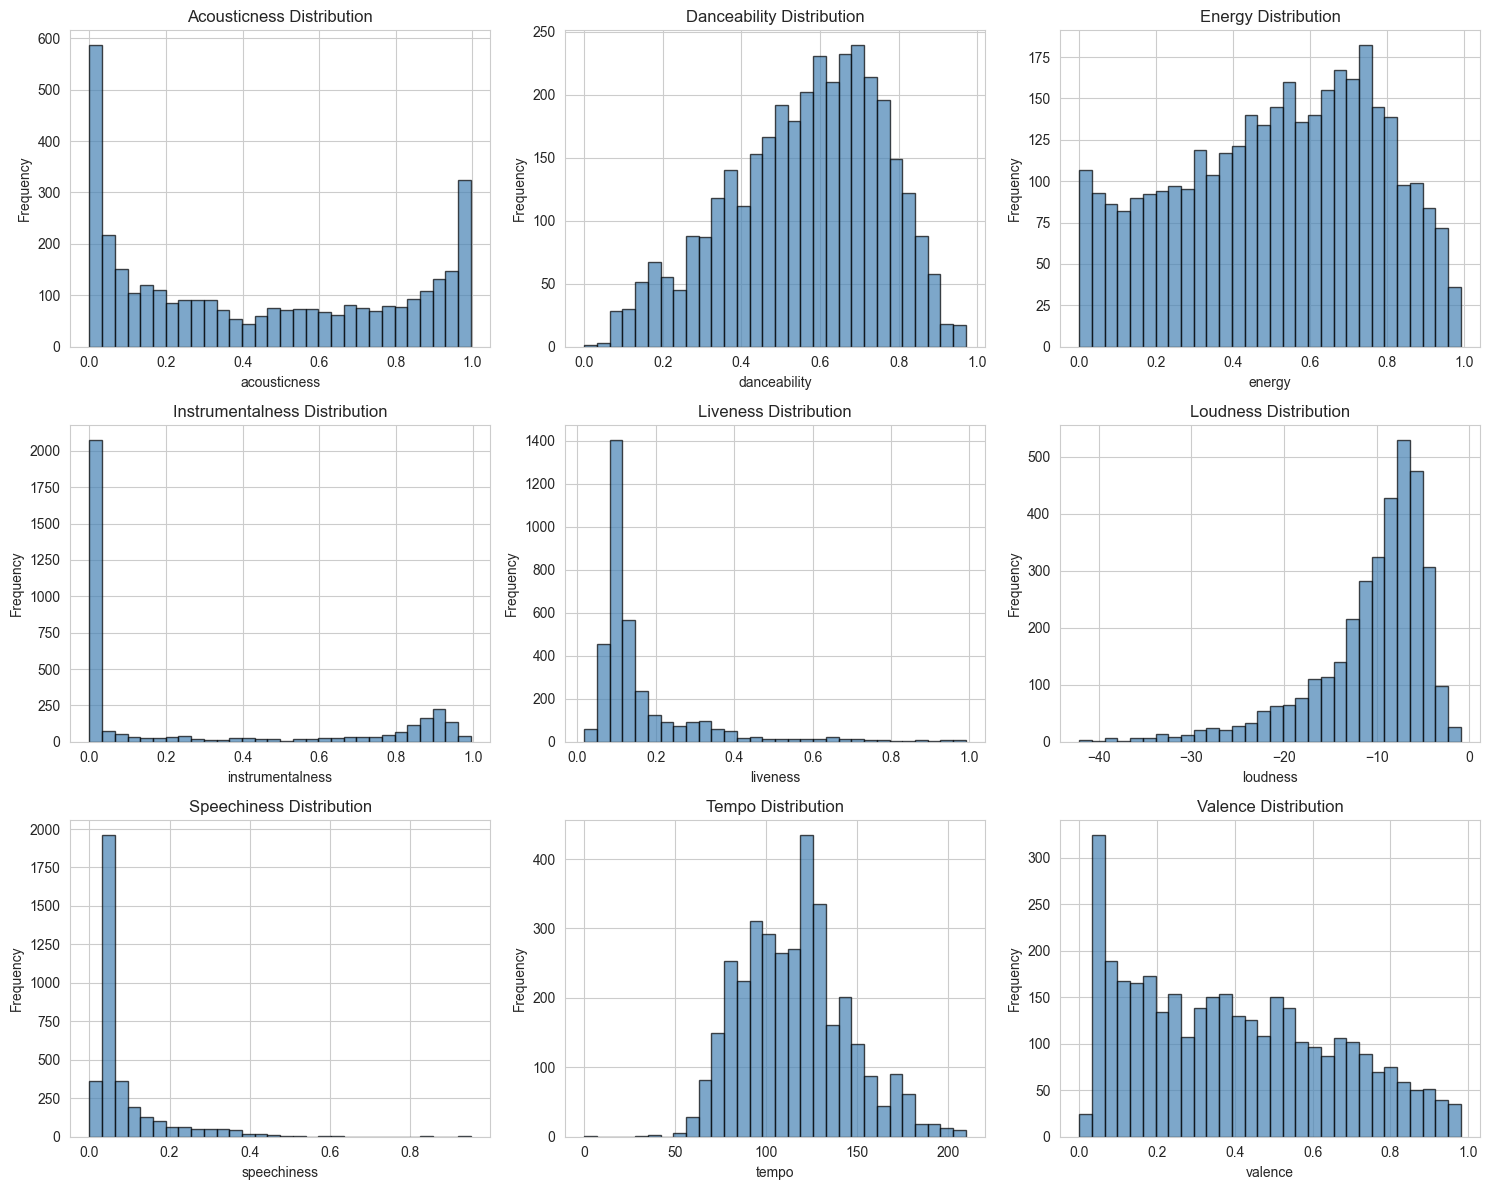

In [12]:
# Distribution of audio features (histograms)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(labeled[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature.capitalize()} Distribution', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5. Analyze Feature Correlations

Understanding correlations helps identify redundant features and relationships between variables.

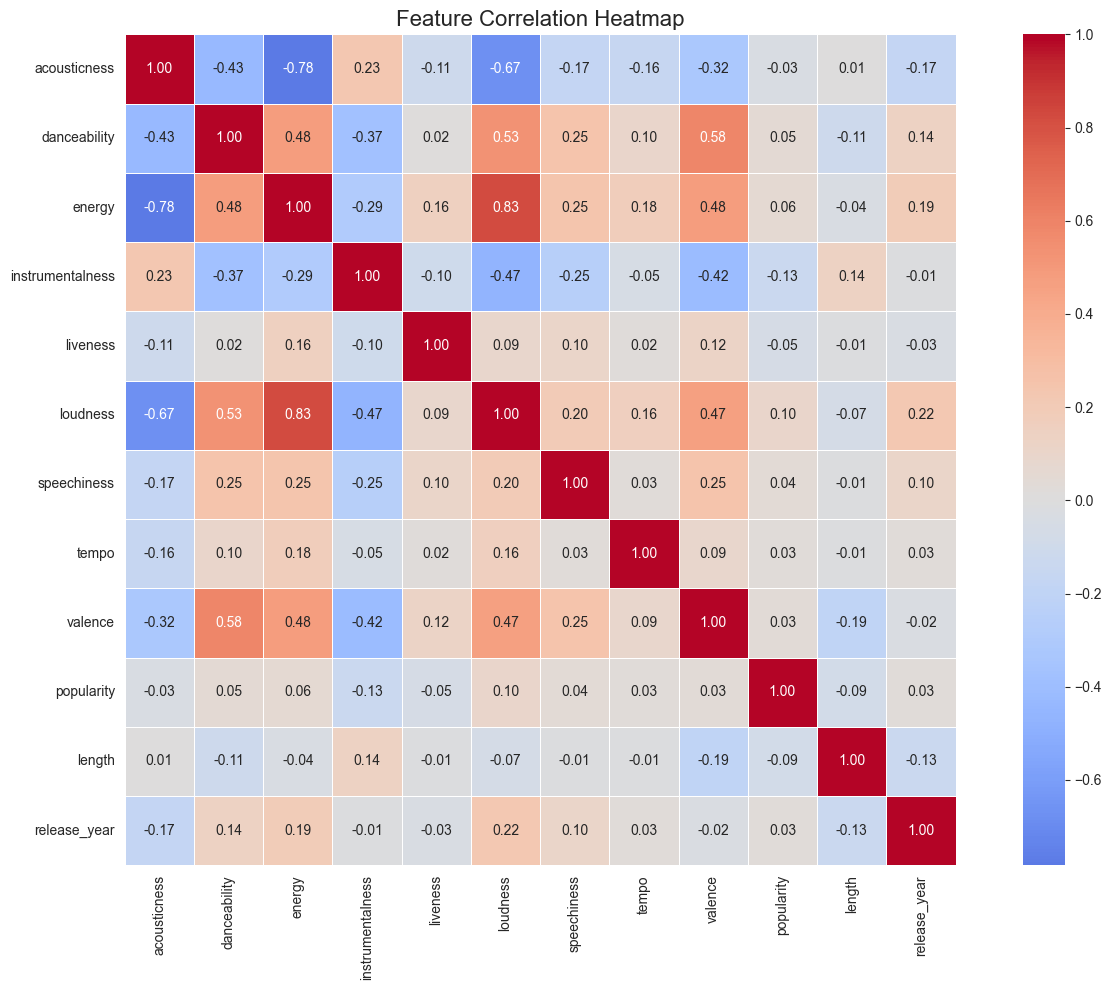

In [13]:
# Correlation matrix for all numeric features
numeric_features = audio_features + ['popularity', 'length', 'release_year']
correlation_matrix = labeled[numeric_features].corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# Identify highly correlated feature pairs (|r| > 0.5)
print("Highly correlated feature pairs (|r| > 0.75):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.75:
            print(f"  {correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

Highly correlated feature pairs (|r| > 0.75):
  acousticness - energy: -0.783
  energy - loudness: 0.826


### 6. Compare User Listening Profiles

Do different users have distinct musical preferences? This is crucial for predicting which user a song belongs to.

In [15]:
# Average feature values per user
user_profiles = labeled.groupby('user')[audio_features].mean()
print("Average Audio Features by User:")
user_profiles.round(3)

Average Audio Features by User:


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
user,,,,,,,,,
alpha,0.415,0.572,0.554,0.299,0.167,-9.370,0.073,118.437,0.472
beta,0.586,0.501,0.396,0.288,0.147,-13.330,0.054,111.449,0.347
delta,0.607,0.506,0.387,0.200,0.175,-12.842,0.073,113.310,0.362
epsilon,0.286,0.546,0.596,0.416,0.167,-9.449,0.083,116.352,0.325
gamma,0.317,0.685,0.618,0.133,0.163,-7.714,0.145,116.946,0.451


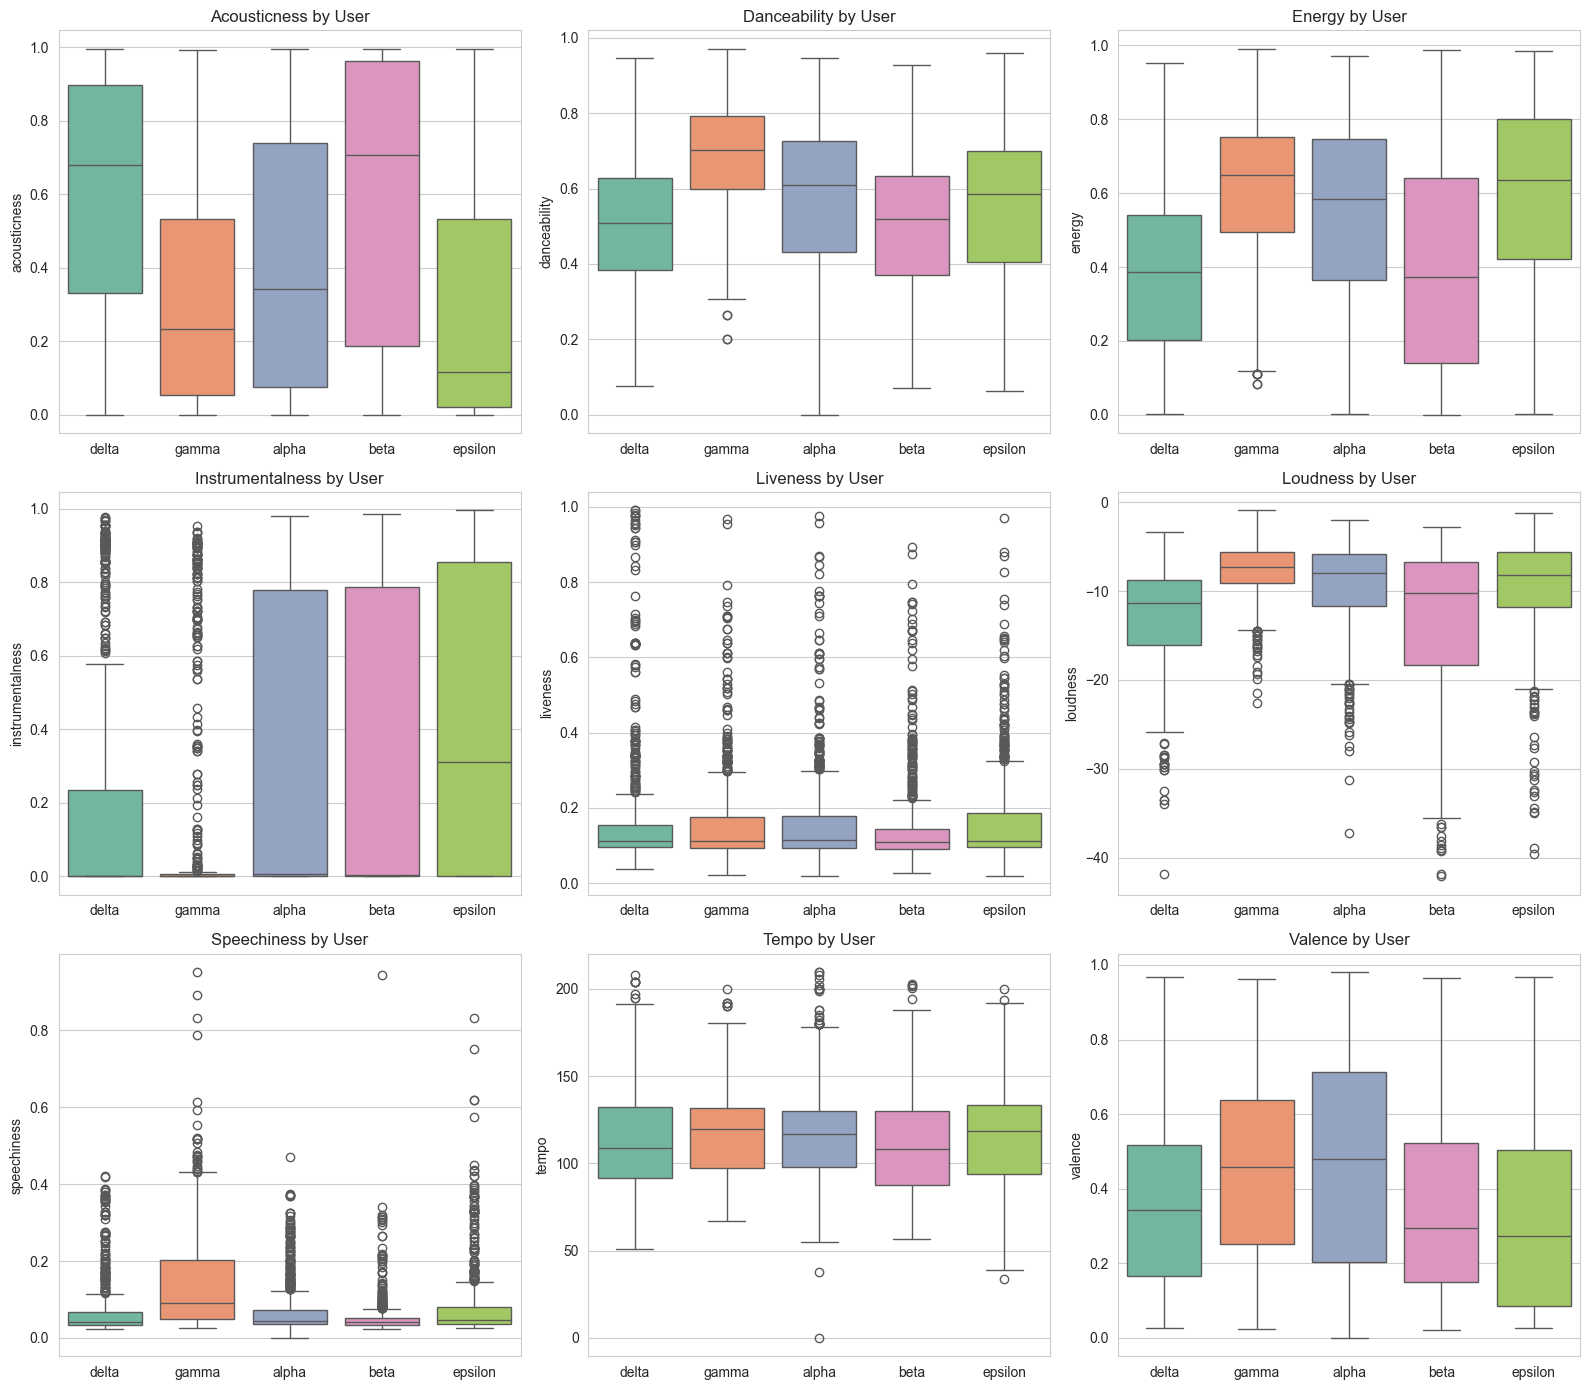

In [16]:
# Boxplots: Feature distributions by user
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.boxplot(data=labeled, x='user', y=feature, ax=axes[i], hue='user', palette='Set2', legend=False)
    axes[i].set_title(f'{feature.capitalize()} by User', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

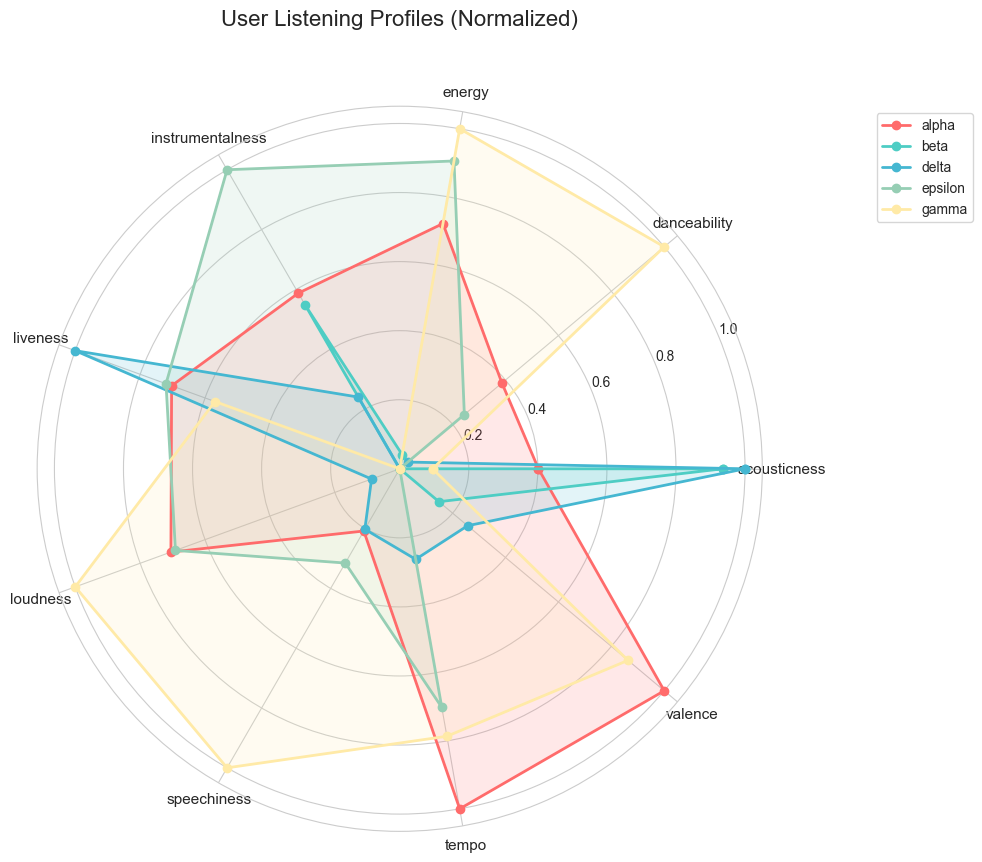

In [17]:
# Normalize features to 0-1 scale for radar chart
user_profiles_norm = (user_profiles - user_profiles.min()) / (user_profiles.max() - user_profiles.min())

# Setup radar chart
categories = audio_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for idx, (user, row) in enumerate(user_profiles_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=user, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_title('User Listening Profiles (Normalized)', size=16, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

### 7. Examine Year-Based Patterns

Do song features vary across different `top_year` values? This helps predict which year a song belongs to.

In [18]:
# Average feature values per top_year
year_profiles = labeled.groupby('top_year')[audio_features].mean()
print("Average Audio Features by Top Year:")
year_profiles.round(3)

Average Audio Features by Top Year:


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
top_year,,,,,,,,,
2019,0.391,0.605,0.561,0.177,0.203,-9.290,0.086,114.885,0.486
2020,0.330,0.603,0.583,0.203,0.171,-8.786,0.085,117.342,0.411
2021,0.411,0.596,0.526,0.202,0.170,-9.786,0.094,115.795,0.424
2022,0.503,0.514,0.454,0.386,0.146,-11.646,0.070,114.408,0.292
2023,0.585,0.504,0.423,0.365,0.150,-13.158,0.084,113.815,0.358
2024,0.440,0.563,0.517,0.308,0.155,-10.772,0.082,115.633,0.391
2025,0.437,0.549,0.507,0.228,0.150,-10.344,0.099,115.217,0.378


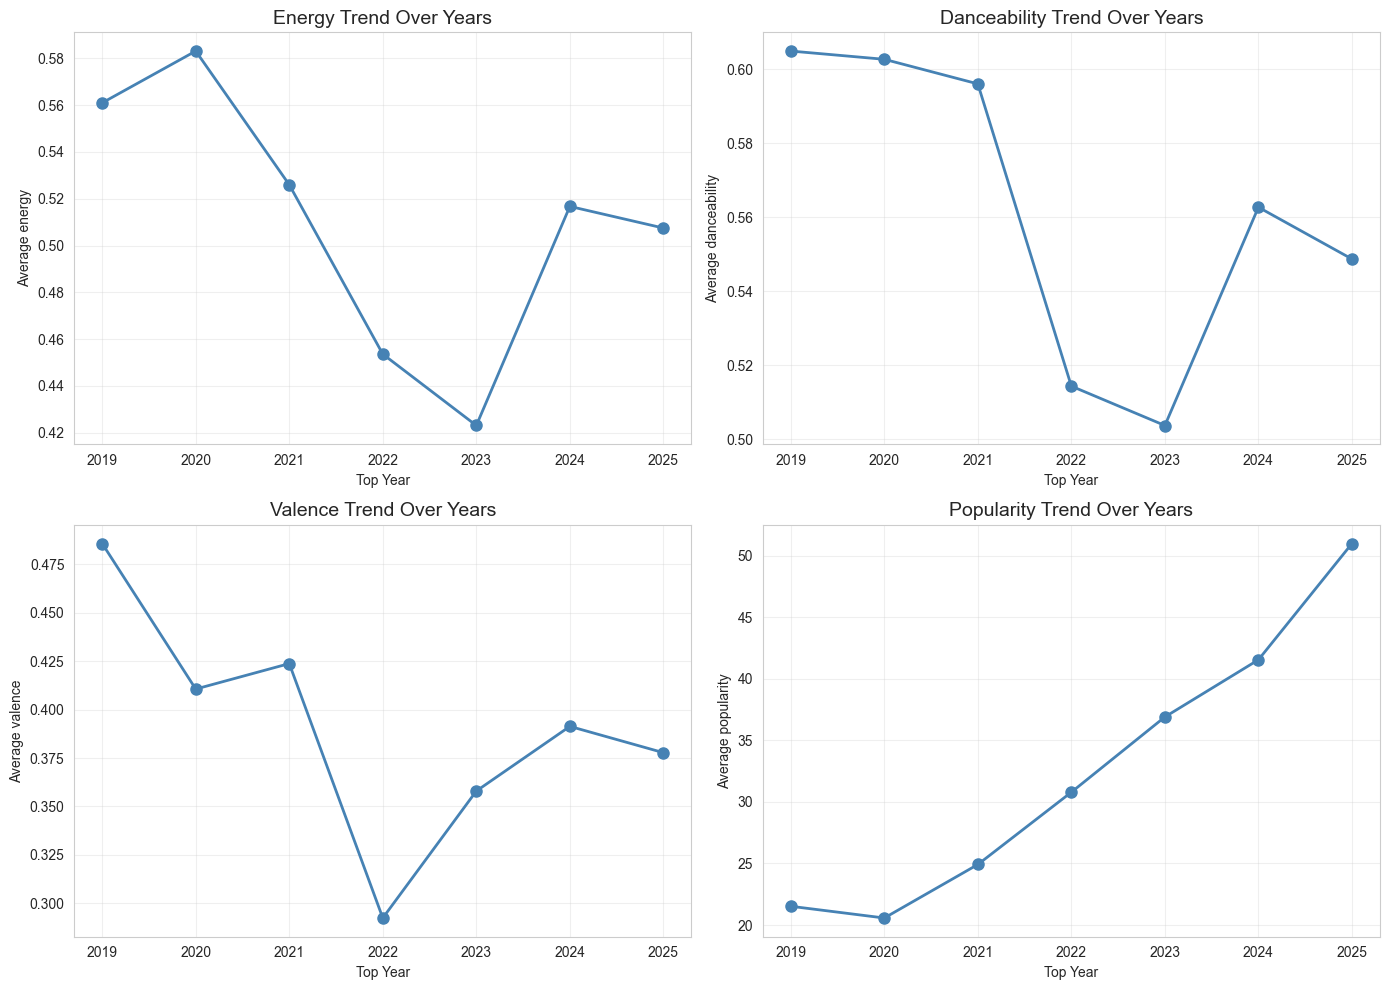

In [19]:
# Trends: Key features over years
key_features = ['energy', 'danceability', 'valence', 'popularity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    year_means = labeled.groupby('top_year')[feature].mean()
    axes[i].plot(year_means.index, year_means.values, 'o-', linewidth=2, markersize=8, color='steelblue')
    axes[i].set_title(f'{feature.capitalize()} Trend Over Years', fontsize=14)
    axes[i].set_xlabel('Top Year')
    axes[i].set_ylabel(f'Average {feature}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

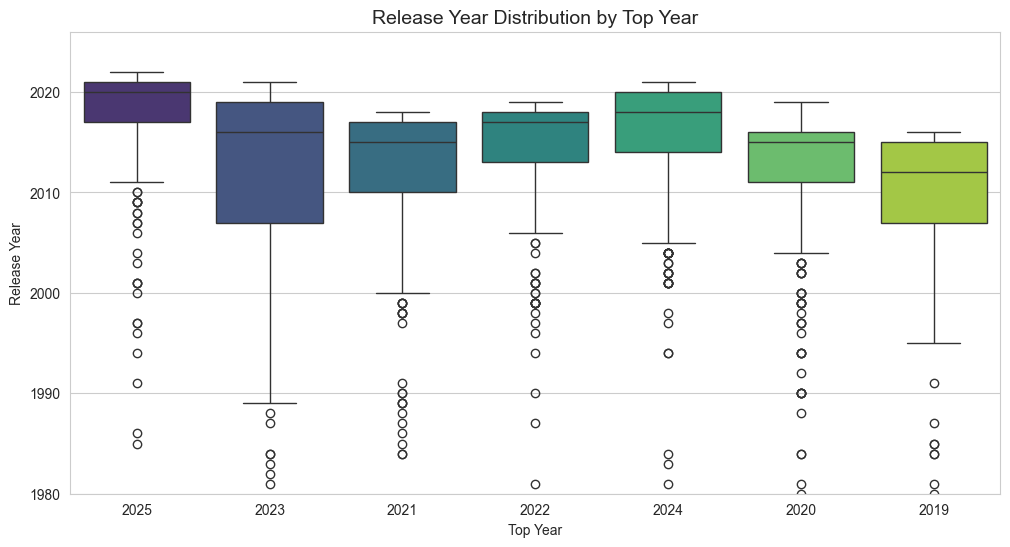


Songs where release_year == top_year: 0 (0.0%)


C:\Users\shubh\AppData\Local\Temp\ipykernel_36924\3998660630.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled.loc[:, 'same_year'] = labeled['release_year'] == labeled['top_year']


In [20]:
# Release year vs Top year relationship
plt.figure(figsize=(12, 6))
sns.boxplot(data=labeled, x='top_year', y='release_year', hue='top_year', palette='viridis', legend=False)
plt.title('Release Year Distribution by Top Year', fontsize=14)
plt.xlabel('Top Year')
plt.ylabel('Release Year')
plt.ylim(1980, 2026)  # Focus on more recent years
plt.show()

# How often is release_year == top_year?
labeled.loc[:, 'same_year'] = labeled['release_year'] == labeled['top_year']
print(f"\nSongs where release_year == top_year: {labeled['same_year'].sum()} ({labeled['same_year'].mean()*100:.1f}%)")

### 7. Summary of Key Findings

Based on our exploration, we can summarize the key insights that will guide our ML approach.

In [21]:
# Summary statistics
print("EXPLORATION SUMMARY")

print(f"\nDataset Overview:")
print(f"   - Total songs: {len(df)}")
print(f"   - Labeled songs: {len(labeled)}")
print(f"   - Unlabeled songs (to predict): {len(unlabeled)}")

print(f"\nUsers (5 classes):")
for user in labeled['user'].unique():
    count = (labeled['user'] == user).sum()
    print(f"   - {user}: {count} songs ({count/len(labeled)*100:.1f}%)")

print(f"\nYears (7 classes): {sorted(labeled['top_year'].unique())}")

print(f"\nFeatures for ML:")
print(f"   - Audio features: {audio_features}")
print(f"   - Additional: popularity, length, release_year, time_signature, key, mode")

print(f"\nKey Observations:")
print("   - Users show distinct preferences in features like energy, danceability")
print("   - Strong correlation between energy and loudness (consider for feature selection)")
print("   - Year prediction may be harder as features don't vary strongly over years")
print("   - release_year could be a useful feature for top_year prediction")

EXPLORATION SUMMARY

Dataset Overview:
   - Total songs: 3591
   - Labeled songs: 3491
   - Unlabeled songs (to predict): 100

Users (5 classes):
   - delta: 696 songs (19.9%)
   - gamma: 700 songs (20.1%)
   - alpha: 700 songs (20.1%)
   - beta: 700 songs (20.1%)
   - epsilon: 695 songs (19.9%)

Years (7 classes): ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

Features for ML:
   - Audio features: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
   - Additional: popularity, length, release_year, time_signature, key, mode

Key Observations:
   - Users show distinct preferences in features like energy, danceability
   - Strong correlation between energy and loudness (consider for feature selection)
   - Year prediction may be harder as features don't vary strongly over years
   - release_year could be a useful feature for top_year prediction


### 8. Data Preprocessing for ML

In [22]:
# One-hot encode categorical features: key, mode, time_signature
categorical_features = ['key', 'mode', 'time_signature']

df_encoded = pd.get_dummies(df, columns=categorical_features, prefix=categorical_features)

# Update labeled and unlabeled dataframes
labeled_encoded = df_encoded[df_encoded['user'] != 'deleted by hacker']
unlabeled_encoded = df_encoded[df_encoded['user'] == 'deleted by hacker']

# Update original dataframes
df = df_encoded
labeled = labeled_encoded
unlabeled = unlabeled_encoded

print(f"Encoded dataset shape: {df.shape}")
print(f"New columns added: {[col for col in df.columns if col not in ['name', 'album', 'artist', 'release_date', 'length', 'popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'time_signature', 'key', 'mode', 'uri', 'release_year', 'top_year', 'user']]}")

Encoded dataset shape: (3591, 38)
New columns added: ['key_0', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'mode_0', 'mode_1', 'time_signature_0', 'time_signature_1', 'time_signature_3', 'time_signature_4', 'time_signature_5']


In [23]:
df.head()

,name,album,artist,release_date,length,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,uri,release_year,top_year,user,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,"Variations on a Polish Theme, Op. 10: No. 5 An...","Szymanowski: Piano Works, Vol. 2",Karol Szymanowski,1996-06-12,76933,53,0.9960,0.329,0.00695,0.866000,0.0906,-34.227,0.0448,70.295,0.238,spotify:track:3bcdLMrAxrfn5dxInjIdI2,1996,deleted by hacker,deleted by hacker,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False
1,Je vous trouve un charme fou - En duo avec Gaë...,Il suffit d'y croire (Version deluxe),Hoshi,2018-30-11,172626,62,0.6220,0.615,0.59900,0.000008,0.1920,-8.715,0.2530,86.976,0.626,spotify:track:0C2yaSWVgCUiiqPyYxSOkd,2018,2025,delta,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,Me Gusta,On ira où ?,DTF,2019-11-10,175269,72,0.4130,0.834,0.73400,0.000040,0.1130,-5.948,0.3410,89.989,0.356,spotify:track:6P3FBaZfUjeWYExU2ShaPZ,2019,2023,gamma,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False
3,L’amour en Solitaire,Petite Amie (Deluxe),Juliette Armanet,2018-02-02,175266,0,0.4040,0.797,0.50600,0.000153,0.2550,-6.774,0.0327,128.027,0.539,spotify:track:2tn51grfchxArwPXeXkoX5,2018,2021,gamma,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
4,Goodnight Moon,Volta,Boogie Belgique,2016-23-09,264735,53,0.0616,0.788,0.67500,0.711000,0.1000,-8.591,0.0318,107.993,0.525,spotify:track:2rvo9Ddv18aRV0OJldhWTf,2016,2023,alpha,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False


In [24]:
scaler = StandardScaler()

numerical_features = audio_features + ['popularity', 'length', 'release_year']

# Convert to float to avoid dtype warnings
labeled = labeled.astype({col: float for col in numerical_features})
unlabeled = unlabeled.astype({col: float for col in numerical_features})

# Fit on labeled data and transform both labeled and unlabeled
labeled.loc[:, numerical_features] = scaler.fit_transform(labeled[numerical_features])
unlabeled.loc[:, numerical_features] = scaler.transform(unlabeled[numerical_features])

print("Numerical features scaled using StandardScaler.")
print(f"Scaled features: {numerical_features}")

Numerical features scaled using StandardScaler.
Scaled features: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'length', 'release_year']


In [25]:
# Feature selection: Remove highly correlated features
features_to_drop = ['loudness', 'acousticness']  # Highly correlated with energy (loudness r=0.826, acousticness r=-0.783)

labeled = labeled.drop(columns=features_to_drop)
unlabeled = unlabeled.drop(columns=features_to_drop)

print(f"Dropped features: {features_to_drop}")
print(f"Labeled data shape after feature selection: {labeled.shape}")
print(f"Unlabeled data shape after feature selection: {unlabeled.shape}")

Dropped features: ['loudness', 'acousticness']
Labeled data shape after feature selection: (3491, 36)
Unlabeled data shape after feature selection: (100, 36)


In [26]:
# Remove non-numeric features that are not useful for ML
non_numeric_features = ['name', 'album', 'artist', 'uri']

# Check if columns exist before dropping
columns_to_drop = [col for col in non_numeric_features if col in labeled.columns]

if columns_to_drop:
    labeled = labeled.drop(columns=columns_to_drop)
    unlabeled = unlabeled.drop(columns=columns_to_drop)
    print(f"Dropped non-numeric features: {columns_to_drop}")
else:
    print("Non-numeric features already removed or not present.")

print(f"Labeled data shape after removing non-numeric features: {labeled.shape}")
print(f"Unlabeled data shape after removing non-numeric features: {unlabeled.shape}")

Dropped non-numeric features: ['name', 'album', 'artist', 'uri']
Labeled data shape after removing non-numeric features: (3491, 32)
Unlabeled data shape after removing non-numeric features: (100, 32)


### 9. Train Test Validation Split

In [27]:
# Stratified train-test split (70-30) on labeled data
labeled['stratify_key'] = labeled['user'].astype(str) + '_' + labeled['top_year'].astype(str)

train_df, test_df = train_test_split(
    labeled,
    test_size=0.30,
    random_state=42,
    stratify=labeled['stratify_key']
)

# Remove stratify_key column
train_df = train_df.drop('stratify_key', axis=1)
test_df = test_df.drop('stratify_key', axis=1)
labeled = labeled.drop('stratify_key', axis=1)

# Define validation_data as unlabeled data (for final prediction)
validation_data = unlabeled.copy()

print(f"\n=== TRAIN-TEST SPLIT (LABELED DATA) ===")
print(f"Training set: {train_df.shape[0]} samples ({train_df.shape[0]/len(labeled)*100:.1f}%)")
print(f"Test set: {test_df.shape[0]} samples ({test_df.shape[0]/len(labeled)*100:.1f}%)")
print(f"Validation set (unlabeled): {validation_data.shape[0]} samples")

print(f"\nTraining set user distribution:\n{train_df['user'].value_counts()}")
print(f"\nTraining set year distribution:\n{train_df['top_year'].value_counts()}")


=== TRAIN-TEST SPLIT (LABELED DATA) ===
Training set: 2443 samples (70.0%)
Test set: 1048 samples (30.0%)
Validation set (unlabeled): 100 samples

Training set user distribution:
user
beta       490
gamma      490
alpha      490
delta      487
epsilon    486
Name: count, dtype: int64

Training set year distribution:
top_year
2025    350
2024    350
2019    350
2023    350
2020    350
2022    347
2021    346
Name: count, dtype: int64


### 10. KNN and SVM Models for User and Top Year prediction

In [28]:
# Prepare feature matrices and encode labels
exclude_cols = ['user', 'top_year', 'track_name', 'album_name', 'artist_name', 'release_date', 'uri']
FEATURE_COLS = [col for col in train_df.columns if col not in exclude_cols]

X_train = train_df[FEATURE_COLS]
y_train_user = train_df['user']
y_train_year = train_df['top_year']

X_test = test_df[FEATURE_COLS]
y_test_user = test_df['user']
y_test_year = test_df['top_year']

X_val = validation_data[FEATURE_COLS]

user_encoder = LabelEncoder()
y_train_user_encoded = user_encoder.fit_transform(y_train_user)
y_test_user_encoded = user_encoder.transform(y_test_user)

year_encoder = LabelEncoder()
y_train_year_encoded = year_encoder.fit_transform(y_train_year)
y_test_year_encoded = year_encoder.transform(y_test_year)

print(f"Feature matrix shapes:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, X_val: {X_val.shape}")
print(f"User classes: {user_encoder.classes_}")
print(f"Year classes: {year_encoder.classes_}")

Feature matrix shapes:
X_train: (2443, 29), X_test: (1048, 29), X_val: (100, 29)
User classes: ['alpha' 'beta' 'delta' 'epsilon' 'gamma']
Year classes: ['2019' '2020' '2021' '2022' '2023' '2024' '2025']


In [29]:
# KNN Model for User Prediction
knn_user = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_user.fit(X_train, y_train_user_encoded)

# KNN Model for Year Prediction
knn_year = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_year.fit(X_train, y_train_year_encoded)

# SVM Model for User Prediction
svm_user = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_user.fit(X_train, y_train_user_encoded)

# SVM Model for Year Prediction
svm_year = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_year.fit(X_train, y_train_year_encoded)

print("KNN and SVM models trained successfully!")

KNN and SVM models trained successfully!


In [30]:
# Evaluate KNN and SVM models on test set
knn_user_pred = knn_user.predict(X_test)
knn_year_pred = knn_year.predict(X_test)

knn_user_acc = accuracy_score(y_test_user_encoded, knn_user_pred)
knn_year_acc = accuracy_score(y_test_year_encoded, knn_year_pred)

svm_user_pred = svm_user.predict(X_test)
svm_year_pred = svm_year.predict(X_test)

svm_user_acc = accuracy_score(y_test_user_encoded, svm_user_pred)
svm_year_acc = accuracy_score(y_test_year_encoded, svm_year_pred)

print("KNN and SVM evaluation completed!")
print(f"KNN - User Accuracy: {knn_user_acc:.4f}, Year Accuracy: {knn_year_acc:.4f}")
print(f"SVM - User Accuracy: {svm_user_acc:.4f}, Year Accuracy: {svm_year_acc:.4f}")

KNN and SVM evaluation completed!
KNN - User Accuracy: 0.4656, Year Accuracy: 0.2281
SVM - User Accuracy: 0.5429, Year Accuracy: 0.3082


### 11. XGBoost Model Implementation

In [31]:
# Train XGBoost for User Prediction
xgb_user = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    objective='multi:softmax',
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_user.fit(X_train, y_train_user_encoded, 
             eval_set=[(X_test, y_test_user_encoded)],
             verbose=False)

# Train XGBoost for Year Prediction
xgb_year = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    objective='multi:softmax',
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_year.fit(X_train, y_train_year_encoded,
             eval_set=[(X_test, y_test_year_encoded)],
             verbose=False)

print("XGBoost models trained successfully!")

XGBoost models trained successfully!


FINAL MODEL COMPARISON - ALL MODELS
Model Performance Summary:
         User Accuracy  Year Accuracy
KNN             0.4656         0.2281
SVM             0.5429         0.3082
XGBoost         0.6174         0.3435


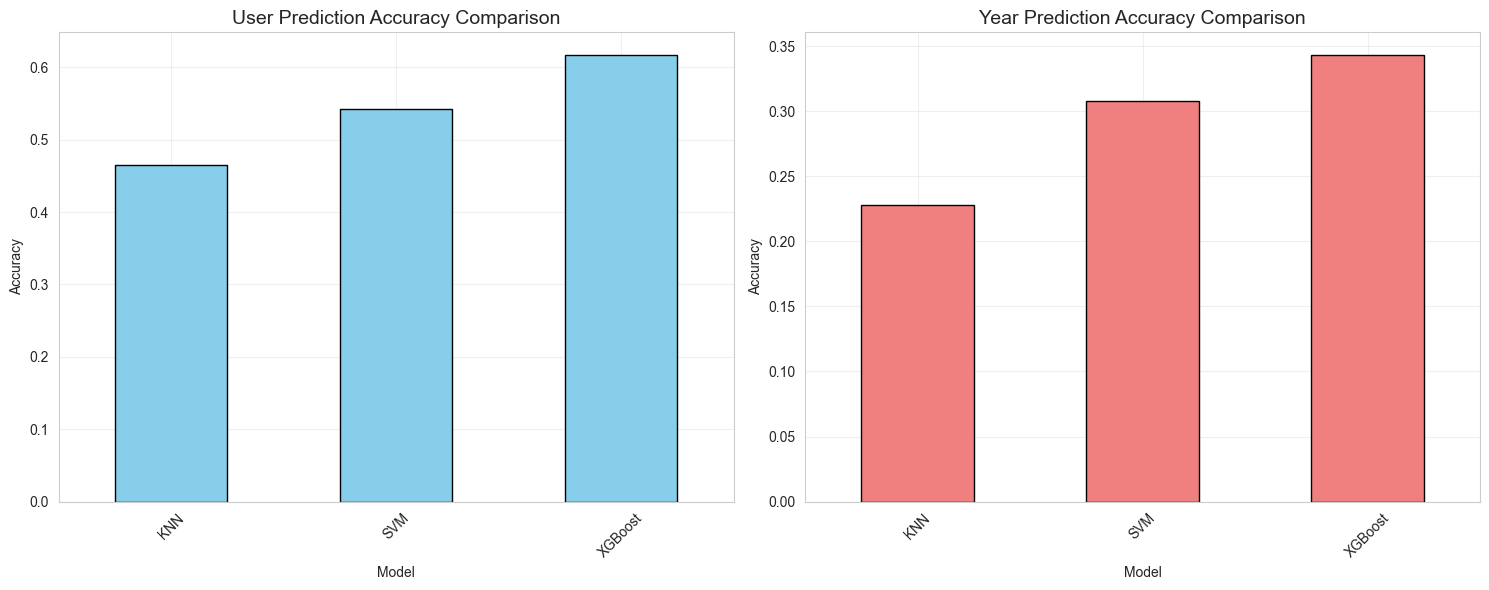

In [32]:
# Evaluate XGBoost on test set
xgb_user_pred = xgb_user.predict(X_test)
xgb_year_pred = xgb_year.predict(X_test)

xgb_user_acc = accuracy_score(y_test_user_encoded, xgb_user_pred)
xgb_year_acc = accuracy_score(y_test_year_encoded, xgb_year_pred)

# Final Model Comparison - All Models
print("FINAL MODEL COMPARISON - ALL MODELS")

# Collect all model accuracies
all_models_comparison = {
    'KNN': {
        'User Accuracy': knn_user_acc,
        'Year Accuracy': knn_year_acc
    },
    'SVM': {
        'User Accuracy': svm_user_acc,
        'Year Accuracy': svm_year_acc
    },
    'XGBoost': {
        'User Accuracy': xgb_user_acc,
        'Year Accuracy': xgb_year_acc
    }
}

# Create comparison DataFrame
all_models_df = pd.DataFrame(all_models_comparison).T
print("Model Performance Summary:")
print(all_models_df.round(4))

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# User accuracy comparison
all_models_df['User Accuracy'].plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('User Prediction Accuracy Comparison', fontsize=14)
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Year accuracy comparison
all_models_df['Year Accuracy'].plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Year Prediction Accuracy Comparison', fontsize=14)
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Final Predictions using XGBoost
print("\nMaking final predictions on validation data using XGBoost...")

# Predict users and years
val_user_pred_encoded = xgb_user.predict(X_val)
val_user_pred = user_encoder.inverse_transform(val_user_pred_encoded)

val_year_pred_encoded = xgb_year.predict(X_val)
val_year_pred = year_encoder.inverse_transform(val_year_pred_encoded)

# Create reconstructed playlists DataFrame
reconstructed_playlists = validation_data.copy()
reconstructed_playlists['predicted_user'] = val_user_pred
reconstructed_playlists['predicted_year'] = val_year_pred

print(f"\nPredictions completed for {len(reconstructed_playlists)} songs")
print(f"Predicted users: {np.unique(val_user_pred, return_counts=True)}")
print(f"Predicted years: {np.unique(val_year_pred, return_counts=True)}")


Making final predictions on validation data using XGBoost...

Predictions completed for 100 songs
Predicted users: (array(['alpha', 'beta', 'delta', 'epsilon', 'gamma'], dtype=object), array([12, 37, 34, 15,  2]))
Predicted years: (array(['2019', '2020', '2021', '2022', '2023', '2024', '2025'],
      dtype=object), array([14,  6,  7,  9, 28,  5, 31]))


In [34]:
# Create playlist reconstruction CSVs
print("\nCreating playlist reconstruction CSVs...")

# Group by user-year combinations
playlist_groups = reconstructed_playlists.groupby(['predicted_user', 'predicted_year'])

for (user, year), group in playlist_groups:
    filename = f"user_{user}_top_{year}.csv"
    group.to_csv(filename, index=False)
    print(f"Created {filename} with {len(group)} songs")

print(f"\nPlaylist reconstruction complete! Created {len(playlist_groups)} playlist files.")

# Summary statistics
print("PLAYLIST RECONSTRUCTION SUMMARY")
print(f"Total songs reconstructed: {len(reconstructed_playlists)}")
print(f"Unique user-year combinations: {len(playlist_groups)}")
print(f"Average songs per playlist: {len(reconstructed_playlists)/len(playlist_groups):.1f}")

# Display sample of reconstructed playlists
print("\nSample of reconstructed playlists:")
for (user, year), group in list(playlist_groups)[:3]:
    print(f"\n{user} - {year} ({len(group)} songs):")
    display_cols = ['name'] if 'name' in group.columns else []
    if display_cols:
        print(group[display_cols].head(3).to_string(index=False))
    else:
        print("Song details not available")

print("XGBoost MODEL IMPLEMENTATION COMPLETE")
print("KNN and SVM models evaluated")
print("XGBoost models trained and evaluated")
print("Playlist reconstruction for 100 unlabeled songs")
print(f"Final accuracies: User {xgb_user_acc:.1%}, Year {xgb_year_acc:.1%}")


Creating playlist reconstruction CSVs...
Created user_alpha_top_2019.csv with 5 songs
Created user_alpha_top_2021.csv with 2 songs
Created user_alpha_top_2022.csv with 1 songs
Created user_alpha_top_2023.csv with 3 songs
Created user_alpha_top_2025.csv with 1 songs
Created user_beta_top_2019.csv with 2 songs
Created user_beta_top_2020.csv with 2 songs
Created user_beta_top_2021.csv with 2 songs
Created user_beta_top_2022.csv with 2 songs
Created user_beta_top_2023.csv with 15 songs
Created user_beta_top_2024.csv with 2 songs
Created user_beta_top_2025.csv with 12 songs
Created user_delta_top_2019.csv with 7 songs
Created user_delta_top_2020.csv with 2 songs
Created user_delta_top_2021.csv with 3 songs
Created user_delta_top_2022.csv with 4 songs
Created user_delta_top_2023.csv with 9 songs
Created user_delta_top_2024.csv with 2 songs
Created user_delta_top_2025.csv with 7 songs
Created user_epsilon_top_2020.csv with 2 songs
Created user_epsilon_top_2022.csv with 2 songs
Created user_e